# License Plate Detection - 02: Locate & Crop the Plate

Among the candidate rectangles, pick the brightest (the white plate), and crop it.

In [1]:
import sys, cv2, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
img=utils.load_image(); res=utils.detect_plate(img)
print('plate found:', res['box'] is not None)
print('plate box (x,y,w,h):', res['box'])

plate found: True
plate box (x,y,w,h): (201, 211, 128, 32)


## 1. Detected plate on the car

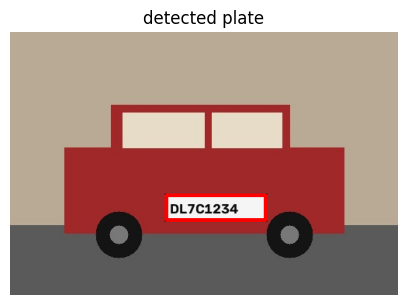

In [2]:
vis=img.copy(); x,y,w,h=res['box']
cv2.rectangle(vis,(x,y),(x+w,y+h),(255,0,0),3)
plt.figure(figsize=(5,4)); plt.imshow(vis); plt.title('detected plate'); plt.axis('off'); plt.show()

## 2. Cropped plate

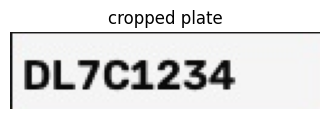

In [3]:
plt.figure(figsize=(4,1.6)); plt.imshow(res['crop']); plt.title('cropped plate'); plt.axis('off'); plt.show()

## 3. Overlap with the ground-truth plate box

In [4]:
gx,gy,gw,gh=[int(v) for v in open('data/plate_bbox.txt').read().split(',')]
x,y,w,h=res['box']
ix=max(0,min(x+w,gx+gw)-max(x,gx)); iy=max(0,min(y+h,gy+gh)-max(y,gy))
inter=ix*iy; union=w*h+gw*gh-inter
print('ground-truth plate:', (gx,gy,gw,gh))
print('detected plate:    ', (x,y,w,h))
print('IoU: %.2f' % (inter/union))

ground-truth plate: (200, 210, 130, 34)
detected plate:     (201, 211, 128, 32)
IoU: 0.93


### Finding
The detector localizes the plate with **IoU ~0.93** against the ground-truth box. Pure geometry: edges -> aspect/area filter -> brightest candidate. On real photos you would add plate-colour models and feed the crop to an OCR step, but the localization is the same classic pipeline.